# Market Sentiment vs Trader Behavior Analysis (Hyperliquid)

This project analyzes how Bitcoin market sentiment (Fear vs Greed) influences trader behavior and performance on Hyperliquid.

The objective is to identify patterns in trading activity, profitability, and risk-taking behavior under different market conditions, and derive actionable insights for improved trading strategies.

## Data Sources

Two datasets were used:

1. **Bitcoin Market Sentiment Dataset**
   - Contains daily sentiment classification (Fear / Greed / Neutral/ Extreme Fear / Extreme Greed )

2. **Hyperliquid Historical Trader Data**
   - Contains trade-level execution data including Account ,Coin, Execution Price , size, side, timestamp, and profit/loss


Both datasets were loaded and inspected for structure, missing values, and consistency.

In [2]:
import pandas as pd

sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

# print(
#     trades.head()
# )
print( sentiment.head())


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


## Data Inspection

In [3]:
sentiment.shape
trades.shape

sentiment.isnull().sum()
trades.isnull().sum()

sentiment.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

## Data Quality Checks

- Checked number of rows and columns for both datasets
- Verified presence of missing values
- Checked for duplicate records

# Data Cleaning and Pre processing

In [4]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

trades['date'] = trades['Timestamp IST'].dt.date
# trades['time'] = trades['Timestamp IST'].dt.time

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
# sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


- The `Timestamp IST` column in the trader dataset was converted into a datetime format.
- A new `date` column was extracted to aggregate trades at a daily level.
- The sentiment dataset already contained daily records, which were aligned using the same date format.

Timestamp was converted to daily granularity for alignment with sentiment data.


# Data Merging

The trader dataset was merged with the sentiment dataset using the `date` column.



In [5]:
merged = trades.merge(sentiment[['date','classification']], on= 'date', how='left')
print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

## **Key Metrics**

## Daily Profit and Loss
Daily PnL was computed at the account level by aggregating trade-level profit/loss.

In [6]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

## Win Rate
A binary win indicator was created based on whether a trade resulted in positive PnL.

In [7]:
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('Account')['win'].mean().reset_index()

In [8]:
print(win_rate)

                                       Account       win
0   0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2   0x271b280974205ca63b716753467d5a371de622ab  0.301917
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4   0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  0.455215
6   0x39cef799f8b69da1995852eea189df24eb5cae3c  0.327668
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6  0.475904
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641  0.234987
9   0x430f09841d65beb3f27765503d0f850b8bce7713  0.484236
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85  0.353445
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  0.486226
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760  0.360364
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  0.401193
14  0x6d6a4b953f202f8df5bed40692e7fd865318264a  0.431795
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  0.345912
16  0x72c6a4624e1dffa724e6d00d6

### Trade Frequency
Number of trades per day was calculated to understand trading intensity under different sentiment conditions.

```
# This is formatted as code
```



In [9]:
trades_per_day = merged.groupby('date').size().reset_index(name='num_trades')

### Directional Bias

Trade direction (Buy/Sell) was analyzed to understand whether traders exhibit long or short bias under different sentiments.*italicised text*

In [10]:
merged['Side'].value_counts(normalize=True)

,proportion
Side,
SELL,0.513805
BUY,0.486195


### Performance Analysis by Market Sentiment

Trader performance was evaluated across Fear and Greed periods using:

- Average PnL
- Win Rate

This helps determine whether market sentiment impacts profitability.

In [11]:
merged.groupby('classification')['Closed PnL'].mean()
merged.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


In [12]:
merged.groupby('classification').size()

,0
classification,
Extreme Fear,21400
Extreme Greed,39992
Fear,61837
Greed,50303
Neutral,37686


In [13]:
merged.groupby('classification')['Size USD'].describe()


,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,5349.731843,22306.826180,0.01,282.4825,766.150,2329.9700,1120971.60
Extreme Greed,39992.0,3112.251565,11061.998403,0.00,106.7575,500.050,1882.8375,665771.71
Fear,61837.0,7816.109931,51914.859249,0.00,235.6300,735.960,2499.9700,3921430.72
Greed,50303.0,5736.884375,30533.418602,0.00,184.1300,555.000,2100.7000,2227114.71
Neutral,37686.0,4782.732661,37461.883466,0.01,175.5400,547.655,1994.2050,3641180.84


In [14]:
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


In [15]:
pd.crosstab(merged['classification'], merged['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


In [16]:
threshold = merged['Size USD'].median()
merged['risk_segment'] = merged['Size USD'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)

In [17]:
freq = merged.groupby('Account').size()
merged['freq_segment'] = merged['Account'].map(lambda x: 'High' if freq[x] > freq.median() else 'Low')

In [18]:
pnl_std = merged.groupby('Account')['Closed PnL'].std()

## Visual Analysis

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

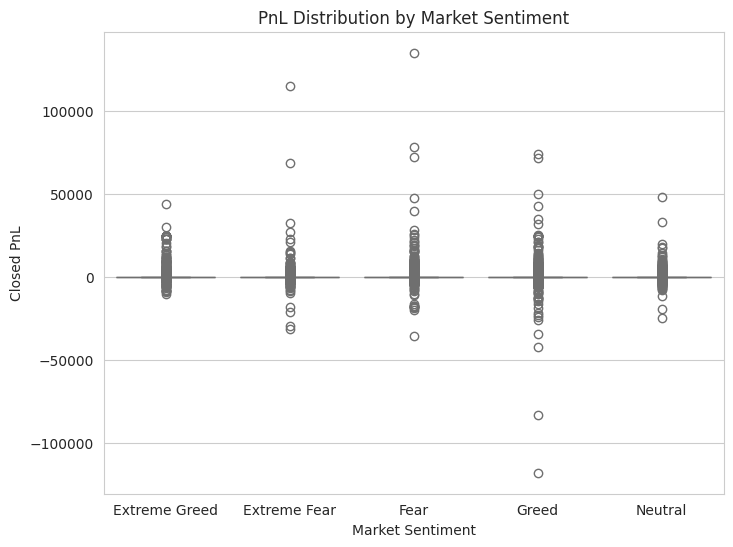

In [41]:
plt.figure(figsize=(8,6))
sns.boxplot(x='classification', y='Closed PnL',
            data=merged ,
            hue='classification',
            palette = 'pastel',
            legend=False)
plt.title('PnL Distribution by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')
plt.show()

/tmp/ipykernel_6747/2279101710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='win', data=win_rate_sentiment, palette='Blues')


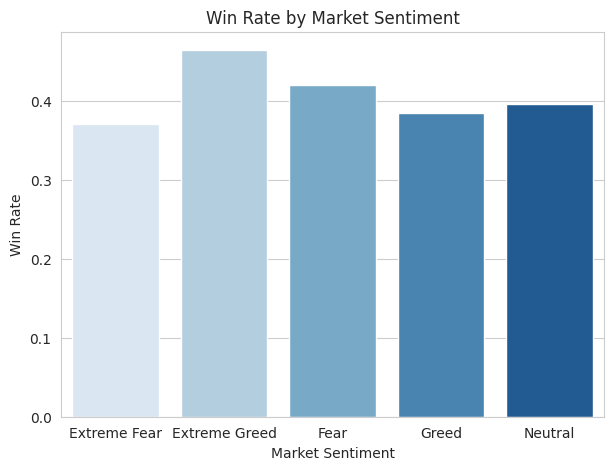

In [31]:
win_rate_sentiment = merged.groupby('classification')['win'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x='classification', y='win', data=win_rate_sentiment, palette='Blues')
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate')
plt.xlabel('Market Sentiment')
plt.show()

/tmp/ipykernel_6747/2338005567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='num_trades', data=trade_activity, palette='viridis')


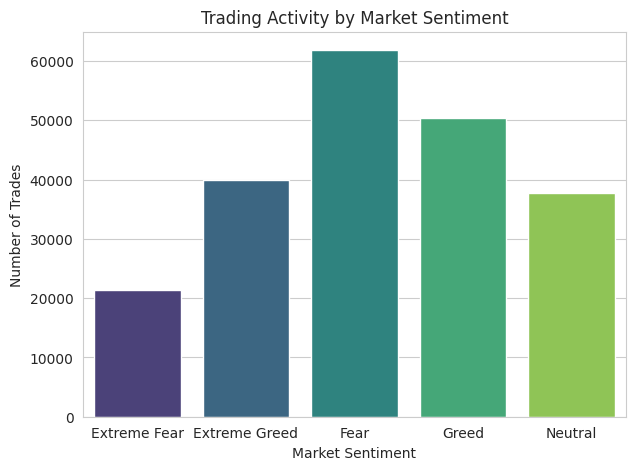

In [33]:
trade_activity = merged.groupby('classification').size().reset_index(name='num_trades')

plt.figure(figsize=(7,5))
sns.barplot(x='classification', y='num_trades', data=trade_activity, palette='viridis')
plt.title('Trading Activity by Market Sentiment')
plt.ylabel('Number of Trades')
plt.xlabel('Market Sentiment')
plt.show()

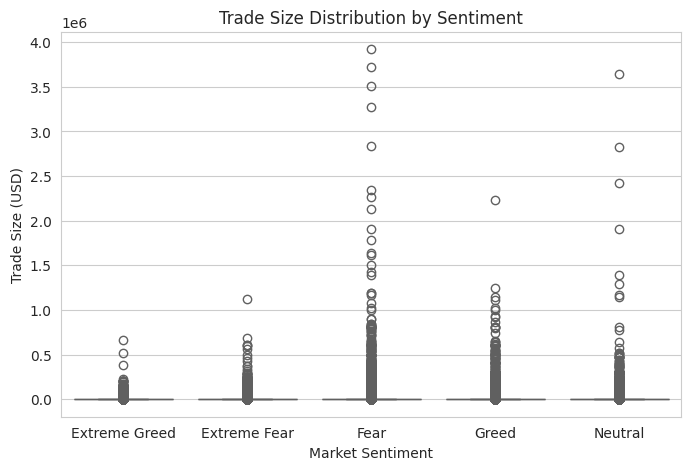

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='classification',
    y='Size USD',
    data=merged,
    hue='classification',
    palette='coolwarm',
    legend=False
)
plt.title('Trade Size Distribution by Sentiment')
plt.ylabel('Trade Size (USD)')
plt.xlabel('Market Sentiment')
plt.show()

## Observations

- No missing values or duplicate records were found, ensuring data reliability for analysis.
- Trading activity is highest during Fear (62k trades) and Greed (50k trades) periods, indicating increased participation during strong sentiment conditions.
- Extreme Fear shows the lowest activity (21k trades), suggesting reduced participation in highly negative market conditions.
- Average trade size is highest during Fear (7816 USD), followed by Greed (5736 USD), indicating higher capital allocation during emotionally driven markets.
- Win rates vary across sentiment regimes, with Extreme Greed (0.46) showing the highest and Extreme Fear (0.37) the lowest.
- Directional bias shows a slight dominance of SELL trades (51.38%) over BUY (48.62%), indicating a marginal bearish tendency overall.

## Key Insights

- Traders are most active during Fear and Greed phases, suggesting that strong market sentiment drives higher engagement and trading frequency.
- Despite higher activity during Fear, profitability does not improve significantly, indicating that increased trading is likely driven by panic rather than strategy.
- The highest average trade size during Fear suggests that traders take larger positions under uncertainty, potentially increasing risk exposure.
- Higher win rates during Extreme Greed indicate that traders perform better in strong upward or trending markets.
- The slight dominance of SELL positions across most sentiment categories suggests a cautious or hedging behavior among traders.
- Overall, trader behavior appears to be influenced more by market sentiment than disciplined decision-making, leading to inefficiencies in performance.

## Strategy Recommendations

- During Fear periods, traders should reduce position sizes and avoid excessive trading, as higher activity does not translate into better profitability.
- Implement stricter risk management during volatile sentiment phases, especially when trade sizes increase significantly.
- During Greed and Extreme Greed periods, traders should avoid overconfidence despite higher win rates and maintain disciplined execution.
- Focus on quality of trades rather than quantity, as increased trade frequency often leads to inconsistent outcomes.